# Parameter inference with HNN

EEG and MEG measure human brain activity with millisecond resolution, but a recorded waveform does not by itself reveal which cellular and circuit processes produced it. Different combinations of synaptic input timing and strength can generate similar macroscopic signals, so a mechanistic interpretation should account for uncertainty rather than rely on a single best-fitting configuration.

The **Human Neocortical Neurosolver (HNN)** connects these scales. It simulates a biophysically detailed cortical column containing pyramidal and basket cells in layers 2/3 and 5. Currents flowing along the aligned dendrites of pyramidal cells produce a current dipole in nAm, which can be compared directly with source-localized EEG/MEG data. The same simulation also exposes otherwise hidden quantities such as cell spiking and layer-specific activity.

HNN can be used to test how the timing and strength of external inputs shape an evoked response, study candidate circuit mechanisms behind brain rhythms or differences between experimental conditions, and generate cellular predictions that can be checked with invasive or non-invasive recordings or targeted experiments.

Parameter inference is challenging because an HNN simulation is stochastic and relatively expensive, while its likelihood is not available in closed form. Neural posterior estimation addresses this by learning from simulated parameter-waveform pairs. Once trained, the network can rapidly estimate a full posterior for new waveforms, returning both plausible parameter values and their uncertainty.

This notebook demonstrates that workflow with a deliberately small cortical column and two external-input parameters. It is an identifiability example rather than a complete fit of an HNN model to experimental data. See [HNN-core](https://joss.theoj.org/papers/10.21105/joss.05848) and the [batch simulation tutorial](https://jonescompneurolab.github.io/textbook/content/08_using_hnn_api/batch_simulation.html).


## What do we estimate?

| HNN parameter | Meaning | Prior |
| --- | --- | --- |
| `mu` | Mean arrival time of a proximal evoked input, in ms (miliseconds). | $$\mu \sim \mathcal{U}(25, 45)$$ |
| `weight_pyr` | AMPA input weight shared by L2/3 and L5 pyramidal cells, in µS (microsiemens) | $$\log w_{\mathrm{pyr}} \sim \mathcal{U}(\log 10^{-4}, \log(8\times10^{-4}))$$ |

**Observables:** the aggregate current-dipole waveform at 66 time points, from 10 to 75 ms. Timing should shift the response; weight should change its amplitude. We smooth for 5 ms, subtract the pre-input baseline, and add Gaussian measurement noise with SD $2\times10^{-6}\;\mathrm{nAm}$.

We fix the 3×3 pyramidal mesh, local connectivity, basket-cell input weight ($10^{-4}\;\mu\mathrm{S}$), input-time spread (3 ms), and synaptic delays. Each simulation uses fresh input-event and measurement-noise randomness. Holding these quantities fixed isolates how input timing and strength affect the dipole.

## Setup

Run `uv sync` and select this repo's Python kernel. The included offline dataset lets you train immediately without installing NEURON. To regenerate it, use Linux, macOS, or WSL with a C/C++ compiler and run `uv sync --extra hnn`. HNN 0.6.1 builds its mechanisms using NEURON 8.2.7; see [HNN installation](https://jonescompneurolab.github.io/textbook/content/01_getting_started/installation.html).

In [5]:
import bayesflow as bf

from tutorials.helpers import hnn

In [6]:
labels = hnn.PARAMETER_LABELS

## Simulate once, train offline

HNN's `BatchSimulate` runs independent parameter draws on fresh network copies. The simulation and waveform utilities live in [hnn.py](helpers/hnn.py). Load the stored simulations below; set `regenerate=True` to generate them again with HNN installed.

In [7]:
train, validation, test = hnn.load_dataset()
print({key: values.shape for key, values in train.items()})

{'mu': (1024, 1), 'weight_pyr': (1024, 1), 'dipole': (1024, 66)}


Each panel overlays the same 40 simulated dipole waveforms. The horizontal axis is time in ms and the vertical axis is current dipole in nAm. Color indicates input arrival time on the left and pyramidal AMPA weight in nS on the right, showing how these parameters affect response timing and amplitude.

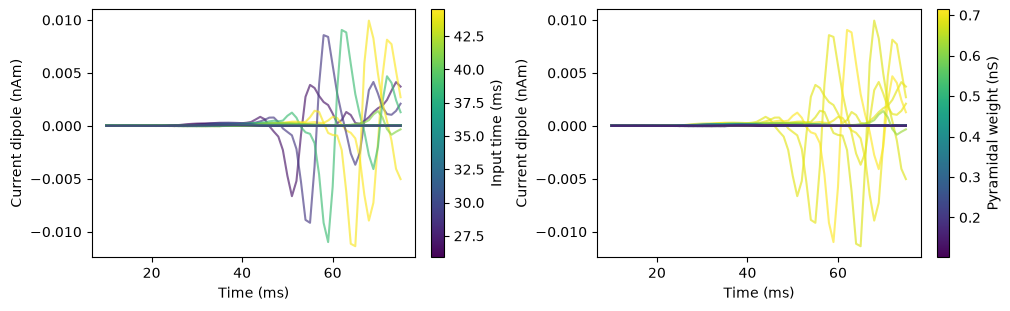

In [11]:
fig = hnn.plot_waveforms(train, n_examples=50)

## Offline NPE through an adapter

The adapter should log-transform the positive weight, concatenate both parameters, and pass the dipole vector as the condition. 

Don't worry, BayesFlow will reverses the transform when sampling, returning weights in µS. Define a small coupling flow (i.e., normalizing flow) to learn $$q_\phi(\mu, w_{\mathrm{pyr}} \mid \mathrm{dipole})$$ from the fixed training set; validation should monitor generalization. No simulator is called during training.

In [ ]:
### Your code here
adapter = None

### Your code here
workflow = None

### Your code here
history = None

The loss plot compares training and validation loss across epochs. Validation uses separate simulations and helps reveal overfitting.

In [ ]:
### Your code here
fig = None

## Does it recover held-out parameters?

Next, condition on 128 unseen dipole waveforms and perform recovery and calibration checks. These checks become much cheaper with amortized inference.

In [ ]:
### Your code here
posterior_samples = None

The recovery plot compares posterior medians and 95% credible intervals with the true simulation parameters. Estimates should follow the diagonal; $r$ reports their correlation with ground truth. Both axes use the same units.

In [ ]:
### Your code here
fig = None

The calibration plot shows the rank ECDF minus the uniform ECDF across held-out simulations. Curves near zero indicate calibration; gray bands show the 95% simultaneous bounds expected under uniform ranks.

In [ ]:
### Your code here
fig = None

Next, summarize recovery, calibration, and posterior contraction numerically in a table:

In [ ]:
### Your code here
table = None

## Next steps

Write down the next steps of the workflow and potential directions for improvement.